In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv")

In [ ]:
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [ ]:
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [3]:
df.isnull().sum()

,0
Unnamed: 0,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
print("Gender:",df['gender'].unique())
print("Private:",df['private'].unique())
print("Freepoor:",df['freepoor'].unique())
print("Freerepat:",df['freerepat'].unique())
print("Nchronic:",df['nchronic'].unique())
print("Lchronic:",df['lchronic'].unique())

Gender: ['female' 'male']
Private: ['yes' 'no']
Freepoor: ['no' 'yes']
Freerepat: ['no' 'yes']
Nchronic: ['no' 'yes']
Lchronic: ['no' 'yes']


Doctor Visits Analysis

In [9]:
print("Number of people for each number of visits:",df['visits'].value_counts().sort_index())

Number of people for each number of visits: visits
0    4141
1     782
2     174
3      30
4      24
5       9
6      12
7      12
8       5
9       1
Name: count, dtype: int64


In [10]:
print("Average visits:",df['visits'].mean())

Average visits: 0.3017341040462428


In [11]:
print("Minimum visits:",df['visits'].min())

Minimum visits: 0


In [12]:
print("Maximum visits:",df['visits'].max())

Maximum visits: 9


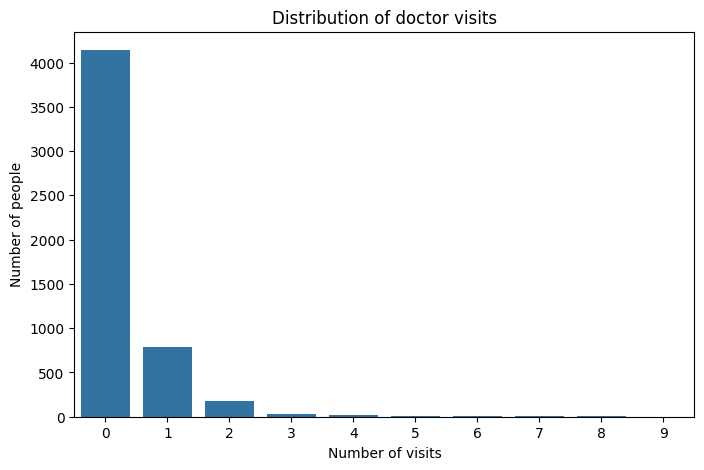

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='visits')
plt.title("Distribution of doctor visits")
plt.xlabel("Number of visits")
plt.ylabel("Number of people")
plt.show()

Gender Analysis

In [14]:
print("Average Visits by gender:",df.groupby('gender')['visits'].mean())

Average Visits by gender: gender
female    0.361954
male      0.236334
Name: visits, dtype: float64


In [15]:
print("Total Visits by gender:",df.groupby('gender')['visits'].sum())

Total Visits by gender: gender
female    978
male      588
Name: visits, dtype: int64


In [16]:
print("Number of people by gender:",df.groupby('gender').value_counts())

Number of people by gender: gender  Unnamed: 0  visits  age   income  illness  reduced  health  private  freepoor  freerepat  nchronic  lchronic
female  1           1       0.19  0.55    1        4        1       yes      no        no         no        no          1
        2           1       0.19  0.45    1        2        1       yes      no        no         no        no          1
        6           1       0.19  0.35    5        1        9       no       no        no         yes       no          1
        7           1       0.19  0.55    4        0        2       no       no        no         no        no          1
        8           1       0.19  0.15    3        0        6       no       no        no         no        no          1
                                                                                                                       ..
male    5182        0       0.19  0.75    1        0        0       no       no        no         no        no          1
 

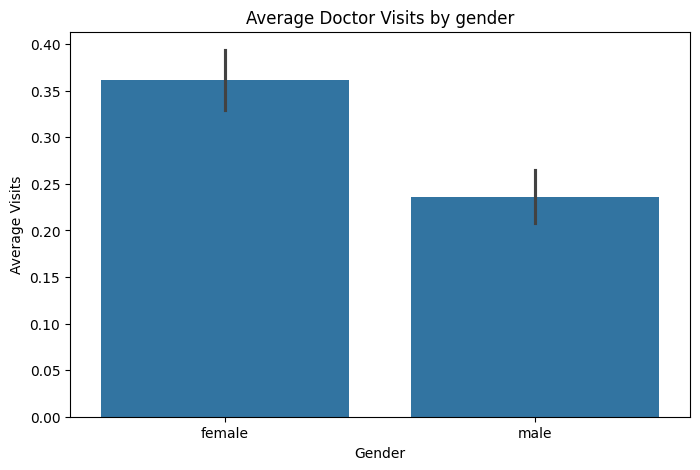

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='gender',y='visits',estimator='mean')
plt.title("Average Doctor Visits by gender")
plt.xlabel("Gender")
plt.ylabel("Average Visits")
plt.show()

Age Analysis

In [18]:
print("Average visits by age:",df.groupby('age')['visits'].mean())

Average visits by age: age
0.19    0.212766
0.22    0.201154
0.27    0.258126
0.32    0.242525
0.37    0.246575
0.42    0.317460
0.47    0.270718
0.52    0.414414
0.57    0.399267
0.62    0.354430
0.67    0.377778
0.72    0.482968
Name: visits, dtype: float64


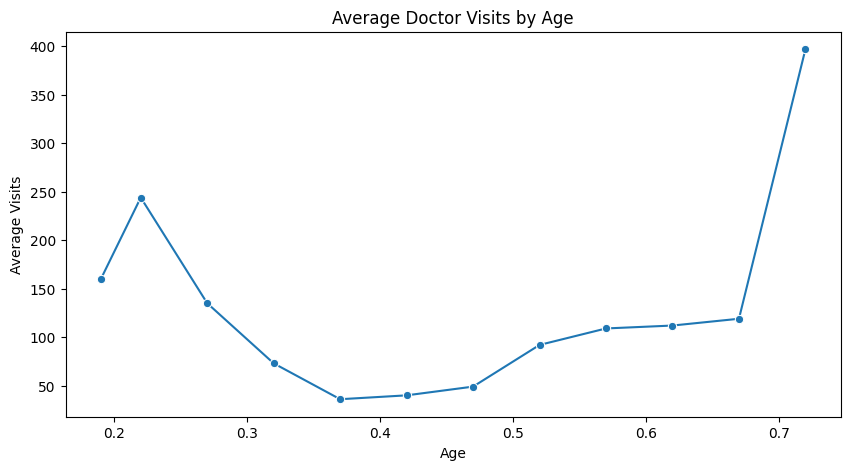

In [19]:
age_visits=df.groupby('age')['visits'].sum().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=age_visits,x='age',y='visits',marker='o')
plt.title("Average Doctor Visits by Age")
plt.xlabel("Age")
plt.ylabel("Average Visits")
plt.show()

Illness Analysis

In [3]:
print("Average visits for each illness count:",df.groupby('illness')['visits'].mean())

Average visits for each illness count: illness
0    0.078507
1    0.295482
2    0.403805
3    0.420664
4    0.576642
5    0.813559
Name: visits, dtype: float64


In [4]:
print("Total visits for each illness count:",df.groupby('illness')['visits'].sum())

Total visits for each illness count: illness
0    122
1    484
2    382
3    228
4    158
5    192
Name: visits, dtype: int64


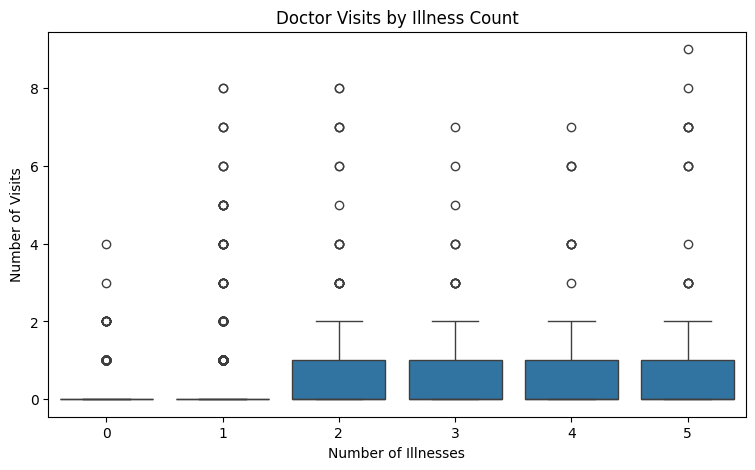

In [5]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df,x='illness',y='visits')
plt.title("Doctor Visits by Illness Count")
plt.xlabel("Number of Illnesses")
plt.ylabel("Number of Visits")
plt.show()

Health Analysis

In [6]:
print("Average visits by health score:",df.groupby('health')['visits'].mean())

Average visits by health score: health
0     0.199273
1     0.335358
2     0.381166
3     0.417582
4     0.534759
5     0.530303
6     0.625000
7     0.918033
8     0.476190
9     0.656250
10    1.523810
11    0.833333
12    1.000000
Name: visits, dtype: float64


In [7]:
print("Total visits by health score:",df.groupby('health')['visits'].sum())

Total visits by health score: health
0     603
1     276
2     170
3     114
4     100
5      70
6      65
7      56
8      20
9      21
10     32
11     20
12     19
Name: visits, dtype: int64


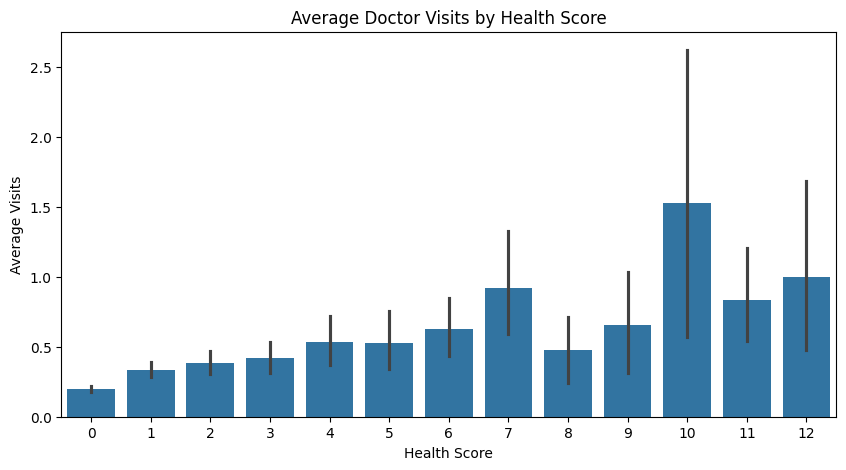

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(data=df,x='health',y='visits',estimator='mean')
plt.title("Average Doctor Visits by Health Score")
plt.xlabel("Health Score")
plt.ylabel("Average Visits")
plt.show()

Chronic Condition Analysis

In [11]:
print("Number of records by chronic condition:",pd.crosstab(
    df['nchronic'],
    df['lchronic']))

Number of records by chronic condition: lchronic    no  yes
nchronic           
no        2493  605
yes       2092    0


In [13]:
print("Average visits:\n",df.groupby(['nchronic','lchronic'])['visits'].mean())

Average visits:
 nchronic  lchronic
no        no          0.191737
          yes         0.603306
yes       no          0.345602
Name: visits, dtype: float64


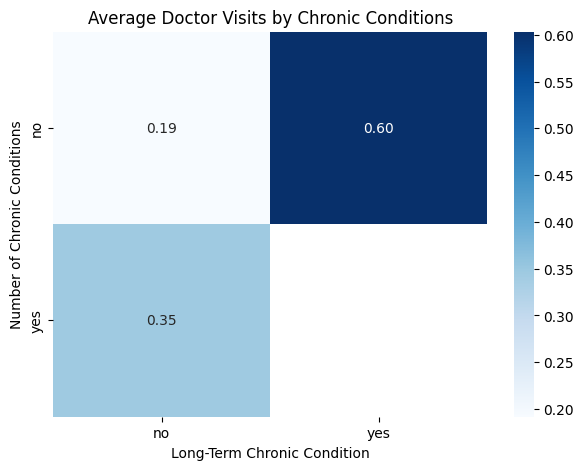

In [14]:
chronic_data = pd.crosstab(
    df["nchronic"],
    df["lchronic"],
    values=df["visits"],
    aggfunc="mean"
)

plt.figure(figsize=(7,5))

sns.heatmap(
    chronic_data,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Average Doctor Visits by Chronic Conditions")
plt.xlabel("Long-Term Chronic Condition")
plt.ylabel("Number of Chronic Conditions")

plt.show()

Private Insurance Analysis

In [15]:
print('Average visits:',df.groupby("private")["visits"].mean())

Average visits: private
no     0.307400
yes    0.294604
Name: visits, dtype: float64


In [16]:
print('Total visits:',df.groupby("private")["visits"].sum())

Total visits: private
no     889
yes    677
Name: visits, dtype: int64


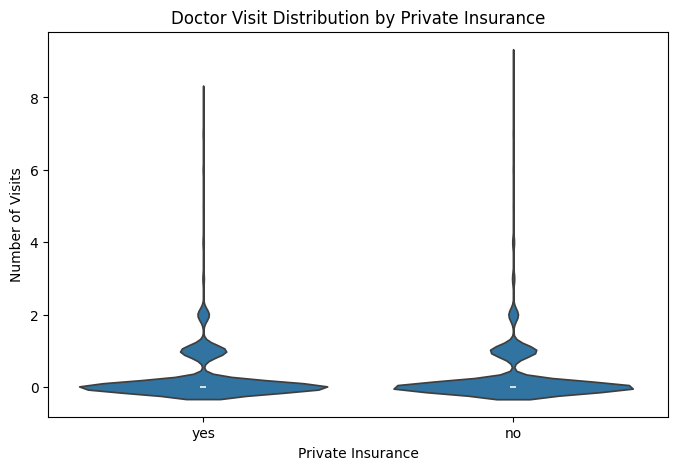

In [17]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="private",
    y="visits"
)

plt.title("Doctor Visit Distribution by Private Insurance")
plt.xlabel("Private Insurance")
plt.ylabel("Number of Visits")

plt.show()

Free/Poor Medical Support Analysis

In [18]:
print('Average visits:',df.groupby("private")["visits"].mean())

Average visits: private
no     0.307400
yes    0.294604
Name: visits, dtype: float64


In [19]:
print('Count of People:',df["freepoor"].value_counts())

Count of People: freepoor
no     4968
yes     222
Name: count, dtype: int64


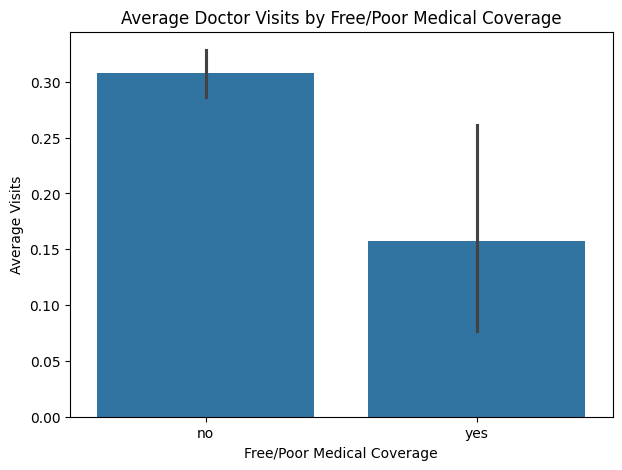

In [20]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="freepoor",
    y="visits",
    estimator="mean"
)

plt.title("Average Doctor Visits by Free/Poor Medical Coverage")
plt.xlabel("Free/Poor Medical Coverage")
plt.ylabel("Average Visits")

plt.show()

Free Repatriation Analysis

In [21]:
print('Average visits:',df.groupby("freerepat")["visits"].mean())

Average visits: freerepat
no     0.257868
yes    0.466544
Name: visits, dtype: float64


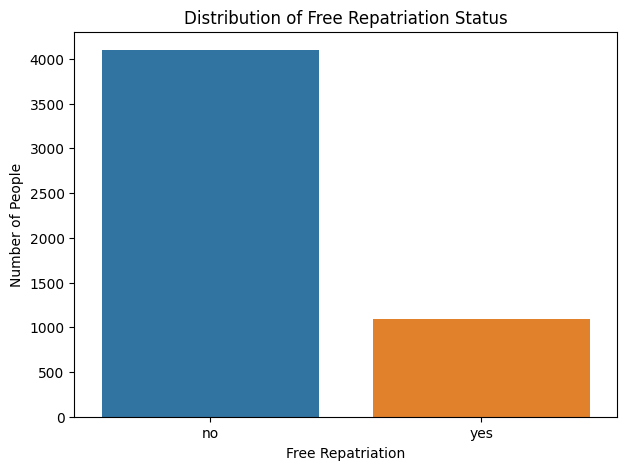

In [22]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="freerepat",
    hue="freerepat",
    legend=False
)

plt.title("Distribution of Free Repatriation Status")
plt.xlabel("Free Repatriation")
plt.ylabel("Number of People")

plt.show()

Income Analysis

In [23]:
print('Average visits by income:',df.groupby("income")["visits"].mean())

Average visits by income: income
0.00    0.367089
0.01    0.485714
0.06    0.200000
0.15    0.349398
0.25    0.420921
0.35    0.359307
0.45    0.305000
0.55    0.252677
0.65    0.246154
0.75    0.244898
0.90    0.207131
1.10    0.177285
1.30    0.277778
1.50    0.265116
Name: visits, dtype: float64


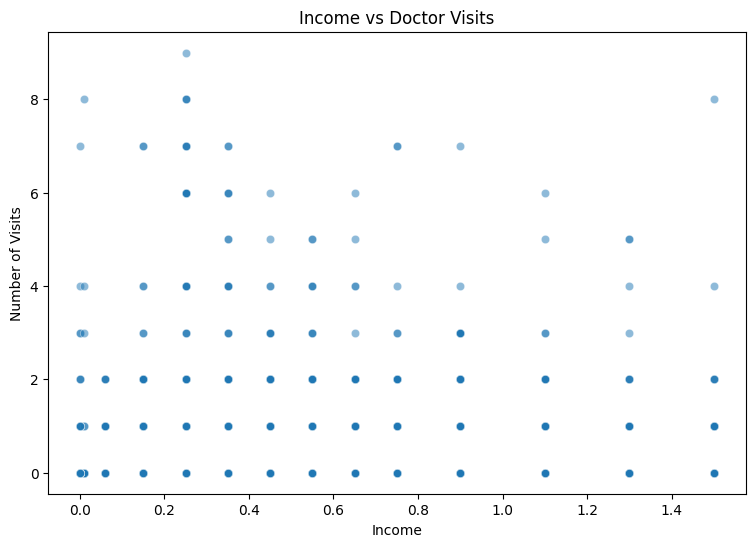

In [24]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="income",
    y="visits",
    alpha=0.5
)

plt.title("Income vs Doctor Visits")
plt.xlabel("Income")
plt.ylabel("Number of Visits")

plt.show()

Correlation Analysis

In [25]:
numeric_columns = [
    "age",
    "income",
    "illness",
    "health",
    "visits"
]

correlation = df[numeric_columns].corr()

correlation

,age,income,illness,health,visits
age,1.000000,-0.271073,0.204984,0.018616,0.124537
income,-0.271073,1.000000,-0.148812,-0.085790,-0.076840
illness,0.204984,-0.148812,1.000000,0.360110,0.223552
health,0.018616,-0.085790,0.360110,1.000000,0.193272
visits,0.124537,-0.076840,0.223552,0.193272,1.000000


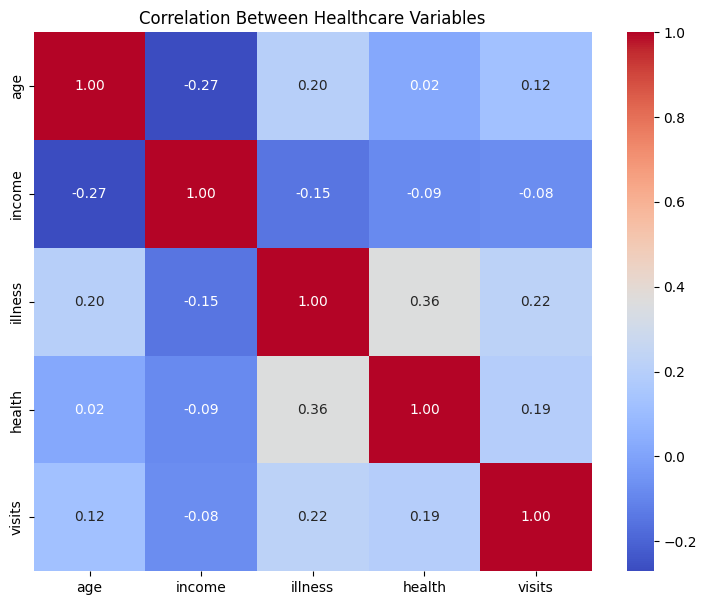

In [26]:
plt.figure(figsize=(9,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Healthcare Variables")

plt.show()